# 07 · Ventanas recientes de entrenamiento y ensembles

**Pregunta:** ¿recortar la historia o combinar modelos mejora el AUC temporal?

Dos pasos, en orden:
1. Comparar toda la historia, 24, 36 y 48 meses con los mismos hiperparámetros ganadores de Optuna y las 42 variables transaccionales.
2. Seleccionar la mejor ventana de cada algoritmo y comparar promedios simples de cada pareja y de los cuatro modelos.

El primer paso aísla el cambio de ventana; **no vuelve a optimizar hiperparámetros**. Las features se calculan con la historia disponible en cada fecha: recortar filas de entrenamiento no recorta su historia transaccional.

Se conservan los cuatro bloques de validación y el gap de seis meses. Los hiperparámetros ya se eligieron en estos bloques; ahora también se seleccionan ventanas y ensembles. Por ello las métricas son de **selección de candidatos**, no una prueba final independiente. El OOT histórico no se evalúa. La meta 0,80 no está garantizada.

Este notebook ejecuta el experimento y guarda cada variante para reanudarla. Puede ejecutarse completo: reutiliza variantes verificadas que ya terminaron. No ejecutar dos copias simultáneamente.

In [1]:
from pathlib import Path
import sys, json, hashlib, itertools, fcntl, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import make_pipeline

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.temporal_optuna import load_raw, temporal_folds, TransactionFeatures, build_model, digest, write_json
from scripts.recent_windows import recent_training_indices, ProbabilityEnsemble
BASE = ROOT / "reports/optuna_temporal_v1"
OUT = ROOT / "reports/recent_windows_v1"
OUT.mkdir(parents=True, exist_ok=True)
MODELS = ["logreg", "rf", "xgboost", "catboost"]
WINDOWS = {"all": None, "24m": 24, "36m": 36, "48m": 48}
THREADS = 4
raw = load_raw()
oot_start = int(raw.mes_rank.max()) - 3
pool = raw[raw.mes_rank <= oot_start - 7].reset_index(drop=True)
folds = temporal_folds(pool)
best = {name: json.loads((BASE / f"{name}_best.json").read_text()) for name in MODELS}
assert all(b["params"]["features"] == "all" for b in best.values())
notebook_path = ROOT / "05_modelling/07_ventanas_recientes_ensemble.ipynb"
notebook = json.loads(notebook_path.read_text())
code_source = "\n".join("".join(c["source"]) for c in notebook["cells"] if c["cell_type"] == "code")
protocol = {"raw_sha256": digest(ROOT / "data/processed/churn_dataset.csv"),
            "backend_sha256": digest(ROOT / "scripts/temporal_optuna.py"),
            "helpers_sha256": digest(ROOT / "scripts/recent_windows.py"),
            "notebook_code_sha256": hashlib.sha256(code_source.encode()).hexdigest(),
            "baseline_params": {name: b["params"] for name, b in best.items()},
            "windows": WINDOWS, "seed": 42, "threads": THREADS,
            "validation": "same four 4-month blocks as temporal_v1, gap=6",
            "ensemble": "equal probability averages: six pairs and all four; best window per model"}
manifest = OUT / "protocol.json"
if manifest.exists() and json.loads(manifest.read_text()) != protocol:
    raise ValueError("Cambió el protocolo: utilizar otro directorio OUT")
write_json(manifest, protocol)
print("Pool:", len(pool), "filas; último mes:", pool.mes_obs.max().date())

Pool: 28311 filas; último mes: 2025-01-01


## 1. Fechas de cada entrenamiento

Para la ventana de 24 meses, por ejemplo, retenemos los ranks entre `último_mes_train - 23` y `último_mes_train`, inclusive. El corte de validación no se mueve. La menor cantidad de filas es parte del experimento.

In [2]:
dates = []
for i, (tr, va) in enumerate(folds):
    for label, months in WINDOWS.items():
        selected = recent_training_indices(pool, tr, months)
        a, b = pool.iloc[selected], pool.iloc[va]
        assert a.mes_rank.max() + 6 < b.mes_rank.min()
        assert a.churn.nunique() == b.churn.nunique() == 2
        dates.append({"fold": i, "window": label, "n_train": len(a),
                      "train_start": a.mes_obs.min(), "train_end": a.mes_obs.max(),
                      "valid_start": b.mes_obs.min(), "valid_end": b.mes_obs.max(),
                      "n_valid": len(b)})
dates = pd.DataFrame(dates)
dates.to_csv(OUT / "windows_dates.csv", index=False)
display(dates)

,fold,window,n_train,train_start,train_end,valid_start,valid_end,n_valid
0,0,all,22492,2016-12-01,2023-03-01,2023-10-01,2024-01-01,1224
1,0,24m,6067,2021-04-01,2023-03-01,2023-10-01,2024-01-01,1224
2,0,36m,7942,2020-04-01,2023-03-01,2023-10-01,2024-01-01,1224
3,0,48m,11136,2019-04-01,2023-03-01,2023-10-01,2024-01-01,1224
4,1,all,23426,2016-12-01,2023-07-01,2024-02-01,2024-05-01,1006
5,1,24m,6027,2021-08-01,2023-07-01,2024-02-01,2024-05-01,1006
6,1,36m,8619,2020-08-01,2023-07-01,2024-02-01,2024-05-01,1006
7,1,48m,10683,2019-08-01,2023-07-01,2024-02-01,2024-05-01,1006
8,2,all,24594,2016-12-01,2023-11-01,2024-06-01,2024-09-01,1110
9,2,24m,6216,2021-12-01,2023-11-01,2024-06-01,2024-09-01,1110


## 2. Métricas comparables y predicciones de validación

Cada variante predice exactamente las mismas filas. AUC objetivo = media de los cuatro bloques, sin ponderar por tamaño. Además mostramos AP por bloque y lift mensual: top 10 % dentro de cada mes, redondeado hacia abajo, con desempate por ID.

El checkpoint contiene scores e identificadores solo en `reports/` (ignorado por Git). Las tablas mostradas son agregadas.

In [3]:
validation = pd.concat([pool.iloc[va].assign(fold=i) for i, (_, va) in enumerate(folds)], ignore_index=True)
validation = validation[["id_vendedor", "mes_rank", "mes_obs", "churn", "fold"]]

def measure(scores):
    aucs, aps = [], []
    for i in range(len(folds)):
        mask = validation.fold.to_numpy() == i
        y = validation.loc[mask, "churn"]
        aucs.append(float(roc_auc_score(y, scores[mask])))
        aps.append(float(average_precision_score(y, scores[mask])))
    monthly = []
    for month, part in validation.assign(score=scores).groupby("mes_obs"):
        top = part.sort_values(["score", "id_vendedor"], ascending=[False, True]).head(max(1, len(part)//10))
        monthly.append({"month": str(month.date()), "lift": float(top.churn.mean()/part.churn.mean()),
                        "precision": float(top.churn.mean()), "n_top": len(top)})
    return {"auc_mean": float(np.mean(aucs)), "auc_std": float(np.std(aucs)),
            "ap_mean": float(np.mean(aps)), "lift_monthly_mean": float(np.mean([m["lift"] for m in monthly])),
            "fold_auc": aucs, "monthly": monthly}

def evaluate_variant(name, window):
    path = OUT / f"predictions_{name}_{window}.parquet"
    if path.exists():
        saved = pd.read_parquet(path)
        pd.testing.assert_frame_equal(saved[validation.columns], validation)
        scores = saved.score.to_numpy()
        assert np.isfinite(scores).all() and ((scores >= 0) & (scores <= 1)).all()
        return scores
    chunks = []
    for i, (tr, va) in enumerate(folds):
        selected = recent_training_indices(pool, tr, WINDOWS[window])
        a, b = pool.iloc[selected], pool.iloc[va]
        transformer = TransactionFeatures().fit(a)
        model = build_model(name, best[name]["params"], a.churn.to_numpy(), THREADS)
        model.fit(transformer.transform(a), a.churn)
        scores = model.predict_proba(transformer.transform(b))[:, 1]
        if window == "all":
            assert np.isclose(roc_auc_score(b.churn, scores), best[name]["metrics"]["fold_metrics"][i]["auc"], atol=1e-12)
        chunks.append(scores)
    scores = np.concatenate(chunks)
    tmp = path.with_suffix(".tmp.parquet")
    validation.assign(score=scores).to_parquet(tmp, index=False)
    tmp.replace(path)
    return scores

## 3. Ejecutar las 16 variantes

Se evalúan cuatro algoritmos × cuatro ventanas × cuatro folds = 64 ajustes, con hiperparámetros fijos. Los resultados anteriores no se sobrescriben. Al reejecutar se cargan las predicciones ya guardadas.

In [4]:
predictions, metrics = {}, {}
with (OUT / "runner.lock").open("w") as lock:
    fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
    for window in WINDOWS:
        for name in MODELS:
            key = f"{name}_{window}"
            start = time.monotonic()
            predictions[key] = evaluate_variant(name, window)
            metrics[key] = measure(predictions[key])
            write_json(OUT / "variant_metrics.json", metrics)
            print(key, "AUC:", round(metrics[key]["auc_mean"], 6),
                  "segundos:", round(time.monotonic() - start, 1), flush=True)
window_results = pd.DataFrame([{ "model": key.rsplit("_", 1)[0], "window": key.rsplit("_", 1)[1],
                                 **{k: v for k, v in value.items() if k not in ["fold_auc", "monthly"]}}
                               for key, value in metrics.items()])
window_results.to_csv(OUT / "window_comparison.csv", index=False)
display(window_results.pivot(index="model", columns="window", values="auc_mean").round(5))

/home/carlos/projects/glamour/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/carlos/projects/glamour/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/carlos/projects/glamour/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/carlos/projects/glamour/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


logreg_all AUC: 0.785935 segundos: 26.4


...

logreg_48m AUC: 0.786556 segundos: 9.5


rf_48m AUC: 0.787576 segundos: 5.7


xgboost_48m AUC: 0.787068 segundos: 1.0


catboost_48m AUC: 0.786446 segundos: 3.5


window,24m,36m,48m,all
model,,,,
catboost,0.78656,0.78627,0.78645,0.78719
logreg,0.78742,0.78770,0.78656,0.78594
rf,0.78743,0.78729,0.78758,0.78833
xgboost,0.78735,0.78680,0.78707,0.78815


## 4. Ensembles simples, sin ajustar pesos al target

Tomamos la mejor ventana de cada algoritmo según el AUC de validación. Combinamos todas las parejas y los cuatro algoritmos mediante promedio aritmético de scores, con pesos iguales definidos antes de mirar el resultado.

No se ajustan pesos con Optuna ni se entrena un meta-modelo con estas mismas etiquetas. Aun así, elegir las ventanas y luego el mejor ensemble sobre estos bloques introduce sesgo de selección. No describimos sus resultados como independientes.

La logística ponderada y los árboles pueden tener distinta escala de scores. El promedio es una alternativa empírica de ranking, no una probabilidad calibrada.

In [5]:
best_windows = {}
for name in MODELS:
    candidates = [f"{name}_{window}" for window in WINDOWS]
    best_windows[name] = max(candidates, key=lambda key: metrics[key]["auc_mean"])
print("Mejores ventanas:", best_windows)
ensemble_components = {}
for names in list(itertools.combinations(MODELS, 2)) + [tuple(MODELS)]:
    key = "mean_" + "_".join(names)
    components = [best_windows[name] for name in names]
    ensemble_components[key] = components
    predictions[key] = np.mean([predictions[c] for c in components], axis=0)
    metrics[key] = measure(predictions[key])
comparison = pd.DataFrame([{ "candidate": key, **{k: v for k, v in value.items() if k not in ["fold_auc", "monthly"]}}
                           for key, value in metrics.items()]).sort_values("auc_mean", ascending=False)
comparison.to_csv(OUT / "all_candidates.csv", index=False)
write_json(OUT / "all_metrics.json", metrics)
write_json(OUT / "ensemble_components.json", ensemble_components)
display(comparison.reset_index(drop=True).round(5))

Mejores ventanas: {'logreg': 'logreg_36m', 'rf': 'rf_all', 'xgboost': 'xgboost_all', 'catboost': 'catboost_all'}


,candidate,auc_mean,auc_std,ap_mean,lift_monthly_mean
0,mean_logreg_xgboost,0.78961,0.00709,0.59533,2.27715
1,mean_logreg_rf,0.78958,0.00794,0.59263,2.27719
2,mean_logreg_rf_xgboost_catboost,0.78952,0.00721,0.59190,2.31948
3,mean_logreg_catboost,0.78935,0.00723,0.59486,2.28522
4,mean_rf_xgboost,0.78847,0.00735,0.58919,2.26705
5,rf_all,0.78833,0.00835,0.58817,2.24678
6,xgboost_all,0.78815,0.00629,0.58657,2.31154
7,mean_rf_catboost,0.78804,0.00756,0.58866,2.27170
8,mean_xgboost_catboost,0.78789,0.00644,0.58898,2.26766
9,logreg_36m,0.78770,0.00757,0.59370,2.23414


## 5. Correlación y estabilidad

Si los scores de dos modelos son casi idénticos, promediarlos difícilmente añade señal. Comparamos correlación de rangos y AUC de cada bloque. La variabilidad entre bloques no es un intervalo de confianza.

,logreg,rf,xgboost,catboost
logreg,1.000,0.974,0.976,0.974
rf,0.974,1.000,0.996,0.994
xgboost,0.976,0.996,1.000,0.997
catboost,0.974,0.994,0.997,1.000


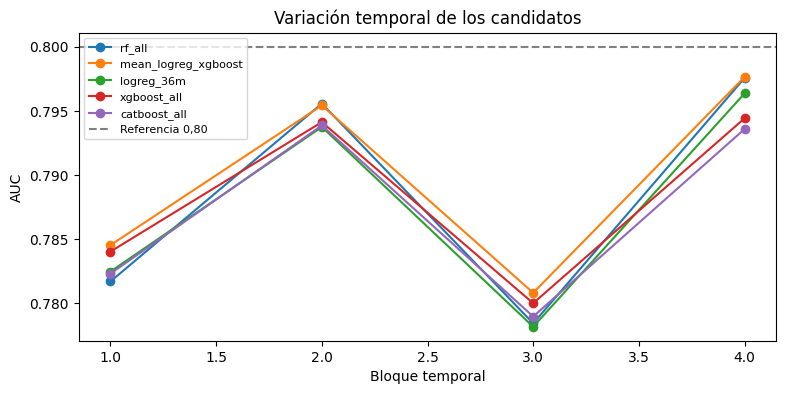

best_candidate                                            mean_logreg_xgboost
best_auc                                                             0.789613
reference_rf_all_auc                                                 0.788326
delta_vs_reference                                                   0.001286
best_windows                {'logreg': 'logreg_36m', 'rf': 'rf_all', 'xgbo...
reached_080_in_selection                                                False
scope                       Selection on reused temporal validations; no i...
dtype: object

In [6]:
score_frame = pd.DataFrame({name: predictions[key] for name, key in best_windows.items()})
display(score_frame.corr(method="spearman").round(3))
chosen = comparison.iloc[0].candidate
baseline = "rf_all"
fig, ax = plt.subplots(figsize=(9, 4))
for key in dict.fromkeys([baseline, chosen] + list(best_windows.values())):
    ax.plot(range(1, 5), metrics[key]["fold_auc"], marker="o", label=key)
ax.axhline(.8, color="gray", linestyle="--", label="Referencia 0,80")
ax.set(xlabel="Bloque temporal", ylabel="AUC", title="Variación temporal de los candidatos")
ax.legend(fontsize=8)
plt.show()
summary = {"best_candidate": chosen, "best_auc": metrics[chosen]["auc_mean"],
           "reference_rf_all_auc": metrics[baseline]["auc_mean"],
           "delta_vs_reference": metrics[chosen]["auc_mean"] - metrics[baseline]["auc_mean"],
           "best_windows": best_windows, "reached_080_in_selection": metrics[chosen]["auc_mean"] >= .8,
           "scope": "Selection on reused temporal validations; no independent final test"}
write_json(OUT / "summary.json", summary)
display(pd.Series(summary))

## 6. Exportar el candidato elegido

Se ajustan sus componentes hasta enero de 2025, respetando la ventana elegida para cada uno. El artefacto acepta filas originales y aplica su transformación transaccional. No se evalúa el OOT ni se afirma que este sea un modelo aprobado para producción.

In [7]:
components = ensemble_components.get(chosen, [chosen])
trained = []
for component in components:
    name, window = component.rsplit("_", 1)
    selected = recent_training_indices(pool, np.arange(len(pool)), WINDOWS[window])
    a = pool.iloc[selected]
    pipeline = make_pipeline(TransactionFeatures(), build_model(name, best[name]["params"], a.churn.to_numpy(), THREADS))
    pipeline.fit(a, a.churn)
    trained.append(pipeline)
    joblib.dump(pipeline, OUT / f"final_{component}.joblib")
artifact = trained[0] if len(trained) == 1 else ProbabilityEnsemble(trained)
joblib.dump(artifact, OUT / "best_candidate.joblib")
reloaded = joblib.load(OUT / "best_candidate.joblib")
np.testing.assert_allclose(artifact.predict_proba(pool.tail(10)), reloaded.predict_proba(pool.tail(10)))
write_json(OUT / "export.json", {"candidate": chosen, "components": components,
           "sha256": digest(OUT / "best_candidate.joblib"), "training_end": str(pool.mes_obs.max().date()),
           "status": "candidate selected on validation; requires final evaluation"})
print("Candidato guardado y recargado correctamente:", chosen)

/home/carlos/projects/glamour/customer-churn-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Candidato guardado y recargado correctamente: mean_logreg_xgboost


## Interpretación

- Si una ventana reciente mejora, es evidencia de que recortar esas filas ayudó bajo los hiperparámetros fijados; no identifica por sí solo la causa.
- Si no mejora, no prueba que toda búsqueda con ventanas recientes fracasaría: los hiperparámetros originales fueron optimizados con toda la historia.
- Si ningún promedio supera los modelos individuales, sus errores pueden ser demasiado parecidos o sus escalas de score poco compatibles.
- No se debe perseguir 0,80 seleccionando repetidamente sobre las mismas validaciones y después presentarlo como resultado en datos nuevos. El siguiente paso requiere confirmación fuera de la selección.